In [ ]:
import skimage.io
import skimage.color
import skimage.filters
import numpy as np
import skimage.measure
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive')
import binvox_rw

In [ ]:
import os
file_paths=[]
directory = '/content/drive/MyDrive/Featurenet_exp/names'

with open(os.path.join(directory, 'file_paths.txt'), 'r') as f:
    file_paths = [line.strip() for line in f]

In [ ]:
file_path=file_paths[17777]

In [ ]:
file_path="/content/swc-h0p1-nth_000001_before.binvox"

In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_3d_array(fp)
       voxels=model.data


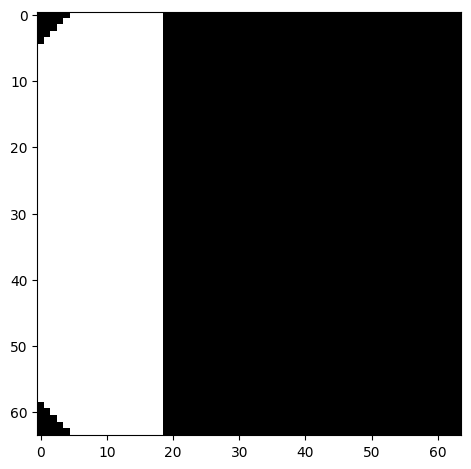

In [ ]:
skimage.io.imshow(voxels[:,:,32])

As our image is in grey scale we just need to create an ndarray

https://medium.com/@betulmesci/image-processing-tutorial-using-scikit-image-connected-component-analysis-5a687293503b



In [ ]:
image=np.zeros(shape=voxels.shape)

In [ ]:
# voxels

In [ ]:
voxels.shape

(64, 64, 64)

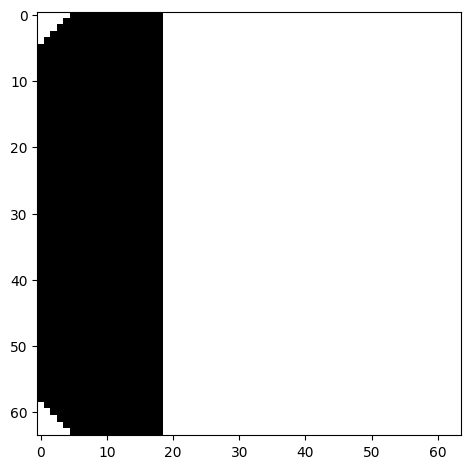

In [ ]:
'''
converting 0 to 1 and 1 to zero
'''
image_inverted=np.ones(shape=voxels.shape)
image_inverted[voxels]=0
skimage.io.imshow(image_inverted[:,:,32])

In [ ]:
'''
We have achieved a labelled volume by using connected component analysis
measure.label returns labelled array where all the connected regions are assigned the same integer value
'''
labeled_image, count = skimage.measure.label(voxels, return_num=True)

print(count)

9


In [ ]:
labeled_image_inverted, count_inverted = skimage.measure.label(image_inverted, return_num=True)

print(count_inverted)

2


In [ ]:
unique_values = np.unique(labeled_image)
len(unique_values)

10

In [ ]:
unique_values = np.unique(labeled_image_inverted)
len(unique_values)

3

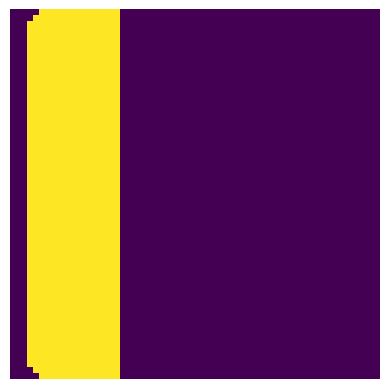

In [ ]:
plt.imshow(labeled_image[:,:,61])
plt.axis('off')
plt.show()

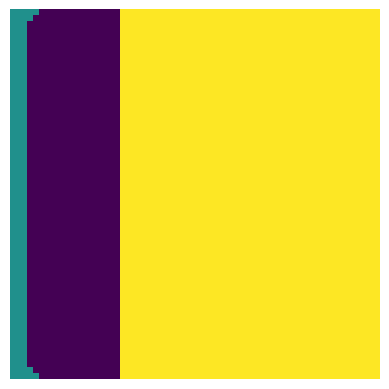

In [ ]:
plt.imshow(labeled_image_inverted[:,:,61])
plt.axis('off')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from binvox_rw import read_as_3d_array


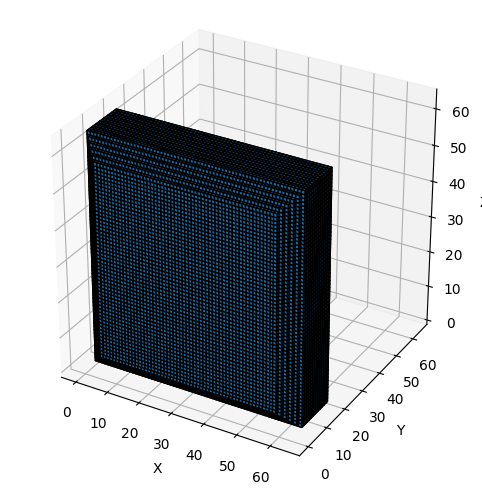

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot voxels
ax.voxels(voxels, edgecolor='k')

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal

# Show plot
plt.show()


In [ ]:
colored_label_image = skimage.color.label2rgb(labeled_image, bg_label=0, colors=( 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'lime'))
colored_label_image.shape

(64, 64, 64, 3)

In [ ]:
colored_label_image_inverted = skimage.color.label2rgb(labeled_image_inverted, bg_label=0, colors=( 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'lime'))
colored_label_image_inverted.shape

(64, 64, 64, 3)

(-0.5, 63.5, 63.5, -0.5)

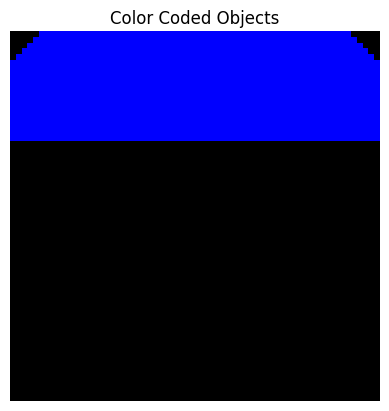

In [ ]:
plt.imshow(colored_label_image[32,:,:])
plt.title('Color Coded Objects')
plt.axis('off')

(-0.5, 63.5, 63.5, -0.5)

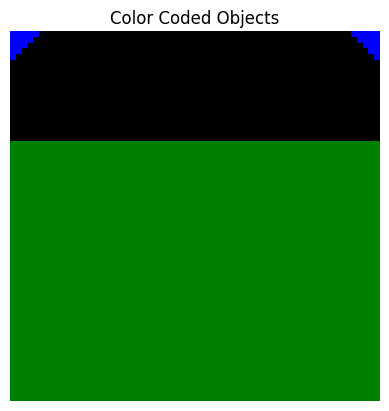

In [ ]:
plt.imshow(colored_label_image_inverted[32,:,:])
plt.title('Color Coded Objects')
plt.axis('off')

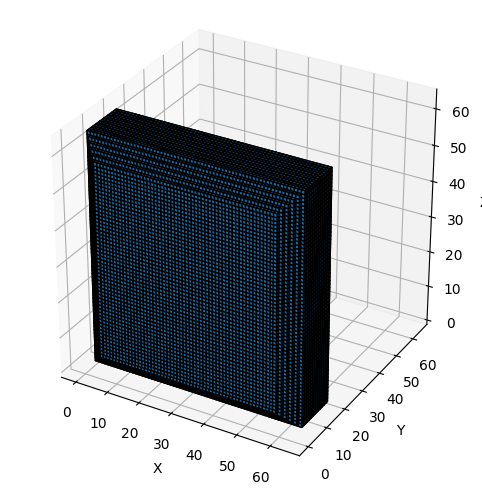

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot voxels
ax.voxels(labeled_image, edgecolor='k')

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal

# Show plot
plt.show()


In [ ]:
properties=skimage.measure.regionprops(labeled_image)

In [ ]:
properties

In [ ]:
colored_label_image.shape

(64, 64, 64, 3)

In [ ]:
'''
bbox is boundary box(min_row,min_col,max_row,max_col)
'''

properties=skimage.measure.regionprops(labeled_image)
for region in properties:
    # Access region properties
    area = region.area  # Area of the region
    bbox = region.bbox  # Bounding box coordinates (min_row, min_col, max_row, max_col)
    centroid = region.centroid  # Centroid coordinates (row, col)
    label = region.label  # Label of the region

    # Print or use the properties as needed
    print(f"Region Label: {label}")
    print(f"Area: {area}")
    print(f"Bbox: {bbox}")
    print(f"Centroid: {centroid}")

Region Label: 1
Area: 71401
Bbox: (0, 0, 0, 64, 19, 64)
Centroid: (30.872004593773198, 9.250164563521519, 32.38370611055868)
Region Label: 2
Area: 2
Bbox: (45, 15, 8, 47, 16, 9)
Centroid: (45.5, 15.0, 8.0)
Region Label: 3
Area: 2
Bbox: (45, 15, 11, 47, 16, 12)
Centroid: (45.5, 15.0, 11.0)
Region Label: 4
Area: 1
Bbox: (48, 15, 8, 49, 16, 9)
Centroid: (48.0, 15.0, 8.0)
Region Label: 5
Area: 1
Bbox: (48, 15, 11, 49, 16, 12)
Centroid: (48.0, 15.0, 11.0)
Region Label: 6
Area: 1
Bbox: (52, 15, 8, 53, 16, 9)
Centroid: (52.0, 15.0, 8.0)
Region Label: 7
Area: 1
Bbox: (52, 15, 11, 53, 16, 12)
Centroid: (52.0, 15.0, 11.0)
Region Label: 8
Area: 1
Bbox: (55, 15, 8, 56, 16, 9)
Centroid: (55.0, 15.0, 8.0)
Region Label: 9
Area: 1
Bbox: (55, 15, 11, 56, 16, 12)
Centroid: (55.0, 15.0, 11.0)


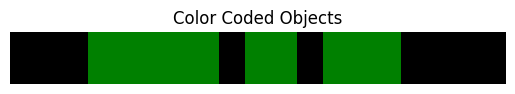

# 45, 15, 8, 47, 16, 9
'''

'''
plt.imshow(colored_label_image[45:47,15,:19])
plt.title('Color Coded Objects')
plt.axis('off')
shows there is a segment in the data that wasnt voxelised well and cretaaed this section for a boundary box


(-0.5, 18.5, 1.5, -0.5)

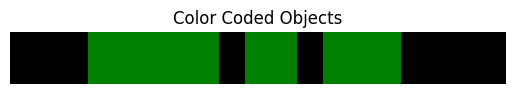

In [ ]:
# 45, 15, 8, 47, 16, 9
'''

'''
plt.imshow(colored_label_image[45:47,15,:19])
plt.title('Color Coded Objects')
plt.axis('off')

In [ ]:
np.unique(colored_label_image)

array([0.   , 0.502, 1.   ])

In [ ]:
objects = skimage.measure.regionprops(labeled_image)
object_areas = [obj["area"] for obj in objects]
print('The areas of the 9 objects are: ')
object_areas

The areas of the 9 objects are: 


[71401, 2, 2, 1, 1, 1, 1, 1, 1]

(71401, (64, 64, 64)) for the converted image the size of the box is the whole image in actuality

In [ ]:
object_areas[0],voxels.shape

(71401, (64, 64, 64))

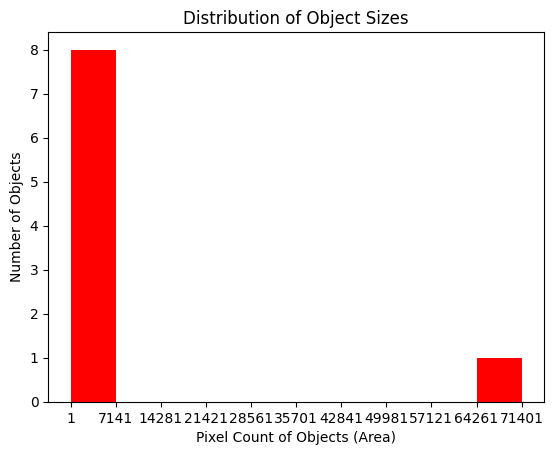

In [ ]:
hist, bin_edges,_=plt.hist(object_areas, color='red')
plt.title("Distribution of Object Sizes")
plt.xlabel("Pixel Count of Objects (Area)")
plt.ylabel("Number of Objects")
plt.xticks(bin_edges[0:])
plt.show()

In [ ]:
objects_inverted = skimage.measure.regionprops(labeled_image_inverted)
object_areas = [obj["area"] for obj in objects_inverted]
print(f"The areas of the {count_inverted} objects are: ")
object_areas

The areas of the 2 objects are: 


[3620, 187113]